In [ ]:
# НАДО ЗАПУСКАТЬ ДВАЖДЫ
import os
import subprocess
import sys
from pathlib import Path

EXTRAS = [
    'hf_transfer', 'oyaml', 'flatten_json', 'lycoris-lora', 'kornia',
    'invisible-watermark', 'bitsandbytes', 'prodigyopt', 'open_clip_torch',
    'lpips', 'optimum-quanto', 'av', 'controlnet-aux', 'torchao>=0.17',
    'torchsde', 'torchdiffeq', 'jsonmerge', 'resize-right', 'clip-anytorch',
    'dctorch',
]
NO_DEPS = ['k-diffusion==0.1.1.post1', 'clean-fid']
SANITY_IMPORTS = (
    'oyaml', 'k_diffusion', 'jsonmerge', 'bitsandbytes', 'kornia', 'lpips',
    'prodigyopt', 'av', 'dctorch', 'cleanfid', 'controlnet_aux',
)
NEUTRALIZED_EXTENSIONS = ('diffusion_models',)
MARKER = '/content/.aitoolkit_deps_installed'


def run_pip(args, label):
    print(f"\n=== {label} ===", flush=True)
    rc = subprocess.run([sys.executable, '-m', 'pip', 'install', *args]).returncode
    if rc:
        raise RuntimeError(f"{label}: pip exit {rc}")


def imports_ok():
    code = ';'.join(f'import {m}' for m in SANITY_IMPORTS)
    return subprocess.run(
        [sys.executable, '-c', code],
        stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    ).returncode == 0


def neutralize_extensions(root):
    for name in NEUTRALIZED_EXTENSIONS:
        path = Path(root) / 'extensions_built_in' / name / '__init__.py'
        if path.exists() and path.read_text().strip():
            path.write_text(f"# {name} disabled\n")
            print(f"Neutralized {name}/__init__.py")


def smoke_test(root):
    proc = subprocess.run(
        [sys.executable, '-c',
         f'import sys; sys.path.insert(0, {root!r}); from toolkit.job import get_job'],
        capture_output=True, text=True,
    )
    if proc.returncode:
        print("--- toolkit.job smoke test failed ---")
        print(proc.stderr)
        return False
    return True


try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
    AI_TOOLKIT = '/content/ai-toolkit'

    if not os.path.exists(AI_TOOLKIT):
        rc = subprocess.run(
            ['git', 'clone', 'https://github.com/ostris/ai-toolkit', AI_TOOLKIT]
        ).returncode
        if rc:
            raise RuntimeError(f"git clone exit {rc}")

    neutralize_extensions(AI_TOOLKIT)

    valid = os.path.exists(MARKER) and imports_ok() and smoke_test(AI_TOOLKIT)
    if os.path.exists(MARKER) and not valid:
        os.remove(MARKER)

    if not valid:
        run_pip(['--upgrade-strategy', 'only-if-needed', *EXTRAS], "extras")
        run_pip(['--no-deps', *NO_DEPS], "no-deps")

        if not imports_ok():
            raise RuntimeError(f"sanity imports failed: {SANITY_IMPORTS}")
        if not smoke_test(AI_TOOLKIT):
            raise RuntimeError("toolkit.job smoke test failed after install")

        Path(MARKER).touch()
        print("\nDeps OK. Kernel restarting — rerun this cell.")
        os.kill(os.getpid(), 9)
    else:
        print("Deps cached, skipping install.")
except ModuleNotFoundError:
    here = Path().resolve()
    DRIVE_ROOT = str(here if (here / 'scripts').exists() else here.parent)
    AI_TOOLKIT = str(Path(DRIVE_ROOT).parent / 'ai-toolkit')
    if not Path(AI_TOOLKIT).exists():
        raise RuntimeError(
            f"ai-toolkit not found at {AI_TOOLKIT}; run setup_local first"
        )

for p in (DRIVE_ROOT, AI_TOOLKIT):
    if p not in sys.path:
        sys.path.insert(0, p)
print(f"DRIVE_ROOT: {DRIVE_ROOT}")
print(f"AI_TOOLKIT: {AI_TOOLKIT}")

In [ ]:
import json
import shutil
from pathlib import Path

from tqdm.auto import tqdm

# На Colab копируем картинки на локальный SSD - Drive раз в 20 медленнее
IS_COLAB = DRIVE_ROOT.startswith('/content/drive')
TRAIN_IMAGES = '/content/data/train_images' if IS_COLAB else f'{DRIVE_ROOT}/data/train_images'


def prepare_aitoolkit_folder(jsonl_path, out_folder, max_items=None):
    """ai-toolkit хочет папку с image.png + image.txt (caption) на каждый пример."""
    out = Path(out_folder)
    out.mkdir(parents=True, exist_ok=True)

    with open(jsonl_path, encoding='utf-8') as f:
        pairs = [json.loads(l) for l in f]
    if max_items:
        pairs = pairs[:max_items]

    existing = {p.stem for p in out.glob('*.png')}
    todo = [p for p in pairs if Path(p['png_path']).stem not in existing]
    print(f"To copy: {len(todo)}  (skipping {len(pairs) - len(todo)} already in {out_folder})")

    bytes_copied = 0
    bar = tqdm(todo, desc="Copying images", unit="file", smoothing=0.1)
    for item in bar:
        stem = Path(item['png_path']).stem
        dst_png = out / f"{stem}.png"
        shutil.copy(item['png_path'], dst_png)
        bytes_copied += dst_png.stat().st_size

        caption = item['caption']
        if not caption.startswith('LOGOIMG'):
            caption = f'LOGOIMG {caption}'
        (out / f"{stem}.txt").write_text(caption, encoding='utf-8')

        if bar.n % 100 == 0:
            bar.set_postfix(MB=f"{bytes_copied / 1e6:.1f}")

    print(f"Prepared {len(pairs)} pairs -> {out_folder}  ({bytes_copied / 1e6:.1f} MB copied)")


prepare_aitoolkit_folder(f'{DRIVE_ROOT}/data/train.jsonl', TRAIN_IMAGES)
print(f"\nTRAIN_IMAGES = {TRAIN_IMAGES}")


In [ ]:
import gc
import os
import sys
import tempfile

# ai-toolkit ждёт эти env-флаги (как в его run.py)
os.environ.setdefault('HF_HUB_ENABLE_HF_TRANSFER', '1')
os.environ.setdefault('NO_ALBUMENTATIONS_UPDATE', '1')
os.environ.setdefault('DISABLE_TELEMETRY', 'YES')
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

if AI_TOOLKIT not in sys.path:
    sys.path.insert(0, AI_TOOLKIT)

import torch
from toolkit.job import get_job

COLAB_ROOT = '/content/drive/MyDrive/liya_diploma'
DRIVE_ROOT_FWD = DRIVE_ROOT.replace('\\', '/')
TRAIN_IMAGES = globals().get(
    'TRAIN_IMAGES',
    '/content/data/train_images' if DRIVE_ROOT.startswith('/content/drive')
    else f'{DRIVE_ROOT_FWD}/data/train_images',
)


def _flush_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def run_aitoolkit(config_path):
    with open(config_path) as f:
        content = f.read()
    # forward slashes — Windows их съест, и YAML не подавится \U
    content = content.replace(COLAB_ROOT, DRIVE_ROOT_FWD)
    content = content.replace(f"{DRIVE_ROOT_FWD}/data/train_images", TRAIN_IMAGES)
    if COLAB_ROOT in content and DRIVE_ROOT_FWD != COLAB_ROOT:
        raise RuntimeError(f"Path substitution failed; '{COLAB_ROOT}' still in config.")

    with tempfile.NamedTemporaryFile(mode='w', suffix='.yaml', delete=False) as f:
        f.write(content)
        tmp = f.name

    job = None
    try:
        job = get_job(tmp)
        job.run()
        job.cleanup()
    finally:
        del job
        os.unlink(tmp)
        _flush_cuda()


for rank in [4, 8, 16, 32]:
    config = f'{DRIVE_ROOT}/configs/sdxl_lora_r{rank}.yaml'
    print(f"\n{'='*50}\nTraining SDXL LoRA r={rank}...")
    run_aitoolkit(config)
    print(f"r={rank}: DONE")
    _flush_cuda()


In [ ]:
import copy
import gc
import os
import sys
import tempfile

import yaml

# повторяем env-флаги чтобы ячейку можно было запустить отдельно
os.environ.setdefault('HF_HUB_ENABLE_HF_TRANSFER', '1')
os.environ.setdefault('NO_ALBUMENTATIONS_UPDATE', '1')
os.environ.setdefault('DISABLE_TELEMETRY', 'YES')
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
if AI_TOOLKIT not in sys.path:
    sys.path.insert(0, AI_TOOLKIT)

import torch
from toolkit.job import get_job

COLAB_ROOT = '/content/drive/MyDrive/liya_diploma'
DRIVE_ROOT_FWD = DRIVE_ROOT.replace('\\', '/')
TRAIN_IMAGES = globals().get(
    'TRAIN_IMAGES',
    '/content/data/train_images' if DRIVE_ROOT.startswith('/content/drive')
    else f'{DRIVE_ROOT_FWD}/data/train_images',
)


def _flush_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def substitute_paths(obj):
    """Рекурсивно заменяет COLAB_ROOT -> DRIVE_ROOT_FWD и подменяет train_images путь."""
    if isinstance(obj, dict):
        return {k: substitute_paths(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [substitute_paths(v) for v in obj]
    if isinstance(obj, str):
        s = obj.replace(COLAB_ROOT, DRIVE_ROOT_FWD)
        return s.replace(f"{DRIVE_ROOT_FWD}/data/train_images", TRAIN_IMAGES)
    return obj


# Поменять на лучший ранг по FID из эксперимента 1 (см. ноутбук 07)
BEST_RANK = 16

with open(f'{DRIVE_ROOT}/configs/sdxl_lora_r{BEST_RANK}.yaml') as f:
    base_cfg = yaml.safe_load(f)

for steps in [500, 1000, 4000]:  # 2000 уже есть из cell 2
    cfg = substitute_paths(copy.deepcopy(base_cfg))
    cfg['config']['name'] = f'sdxl_logo_lora_r{BEST_RANK}_s{steps}'
    cfg['config']['process'][0]['training_folder'] = (
        f'{DRIVE_ROOT_FWD}/results/experiments/sdxl_r{BEST_RANK}_s{steps}'
    )
    cfg['config']['process'][0]['train']['steps'] = steps

    with tempfile.NamedTemporaryFile(mode='w', suffix='.yaml', delete=False) as tf:
        yaml.dump(cfg, tf)
        tmp = tf.name

    job = None
    try:
        print(f"\nTraining r={BEST_RANK}, steps={steps}...")
        job = get_job(tmp)
        job.run()
        job.cleanup()
        print(f"r={BEST_RANK}, steps={steps}: DONE")
    finally:
        del job
        os.unlink(tmp)
        _flush_cuda()


In [ ]:
import re
from pathlib import Path

import torch
from diffusers import StableDiffusionXLPipeline

TEST_PROMPTS = [
    "LOGOIMG minimalist coffee shop logo, circular, dark green, flat vector design",
    "LOGOIMG tech startup logo, geometric hexagon, blue gradient, sans-serif",
    "LOGOIMG bakery logo, wheat icon, warm brown, handcrafted artisan style",
    "LOGOIMG fitness brand, bold lion silhouette, orange and black, geometric",
    "LOGOIMG law firm, balanced scales, navy blue, serif elegant typography",
]


def find_lora_safetensors(training_folder):
    """ai-toolkit кладёт финальные веса в <folder>/<run_name>/<run_name>.safetensors,
    промежуточные имеют суффикс _<step>. Берём финальные."""
    folder = Path(training_folder)
    candidates = [p for p in folder.rglob('*.safetensors')
                  if not re.search(r'_\d{6,}\.safetensors$', p.name)]
    if not candidates:
        raise FileNotFoundError(f"No final LoRA safetensors under {training_folder}")
    canonical = [p for p in candidates if p.stem == p.parent.name]
    return str(canonical[0] if canonical else candidates[0])


def generate_samples(lora_path, out_dir):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    weights = find_lora_safetensors(lora_path)
    pipe = StableDiffusionXLPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-base-1.0",
        torch_dtype=torch.float16,
    ).to("cuda")
    pipe.load_lora_weights(weights)
    pipe.set_progress_bar_config(disable=True)

    for i, prompt in enumerate(TEST_PROMPTS):
        imgs = pipe(
            prompt,
            negative_prompt="photorealistic, blurry, cluttered, complex background",
            num_images_per_prompt=2,
            generator=torch.Generator(device='cuda').manual_seed(42),
            guidance_scale=7.5,
            num_inference_steps=30,
            height=512, width=512,
        ).images
        for j, img in enumerate(imgs):
            img.save(f"{out_dir}/prompt{i:02d}_v{j}.png")

    del pipe
    torch.cuda.empty_cache()
    print(f"Saved samples -> {out_dir}")


for rank in [4, 8, 16, 32]:
    generate_samples(
        f'{DRIVE_ROOT}/results/experiments/sdxl_r{rank}',
        f'{DRIVE_ROOT}/results/experiments/sdxl_r{rank}_samples',
    )

BEST_RANK = globals().get('BEST_RANK', 16)
for steps in [500, 1000, 4000]:
    generate_samples(
        f'{DRIVE_ROOT}/results/experiments/sdxl_r{BEST_RANK}_s{steps}',
        f'{DRIVE_ROOT}/results/experiments/sdxl_r{BEST_RANK}_s{steps}_samples',
    )


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB. GPU 0 has a total capacity of 15.92 GiB of which 0 bytes is free. Of the allocated memory 28.79 GiB is allocated by PyTorch, and 971.88 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

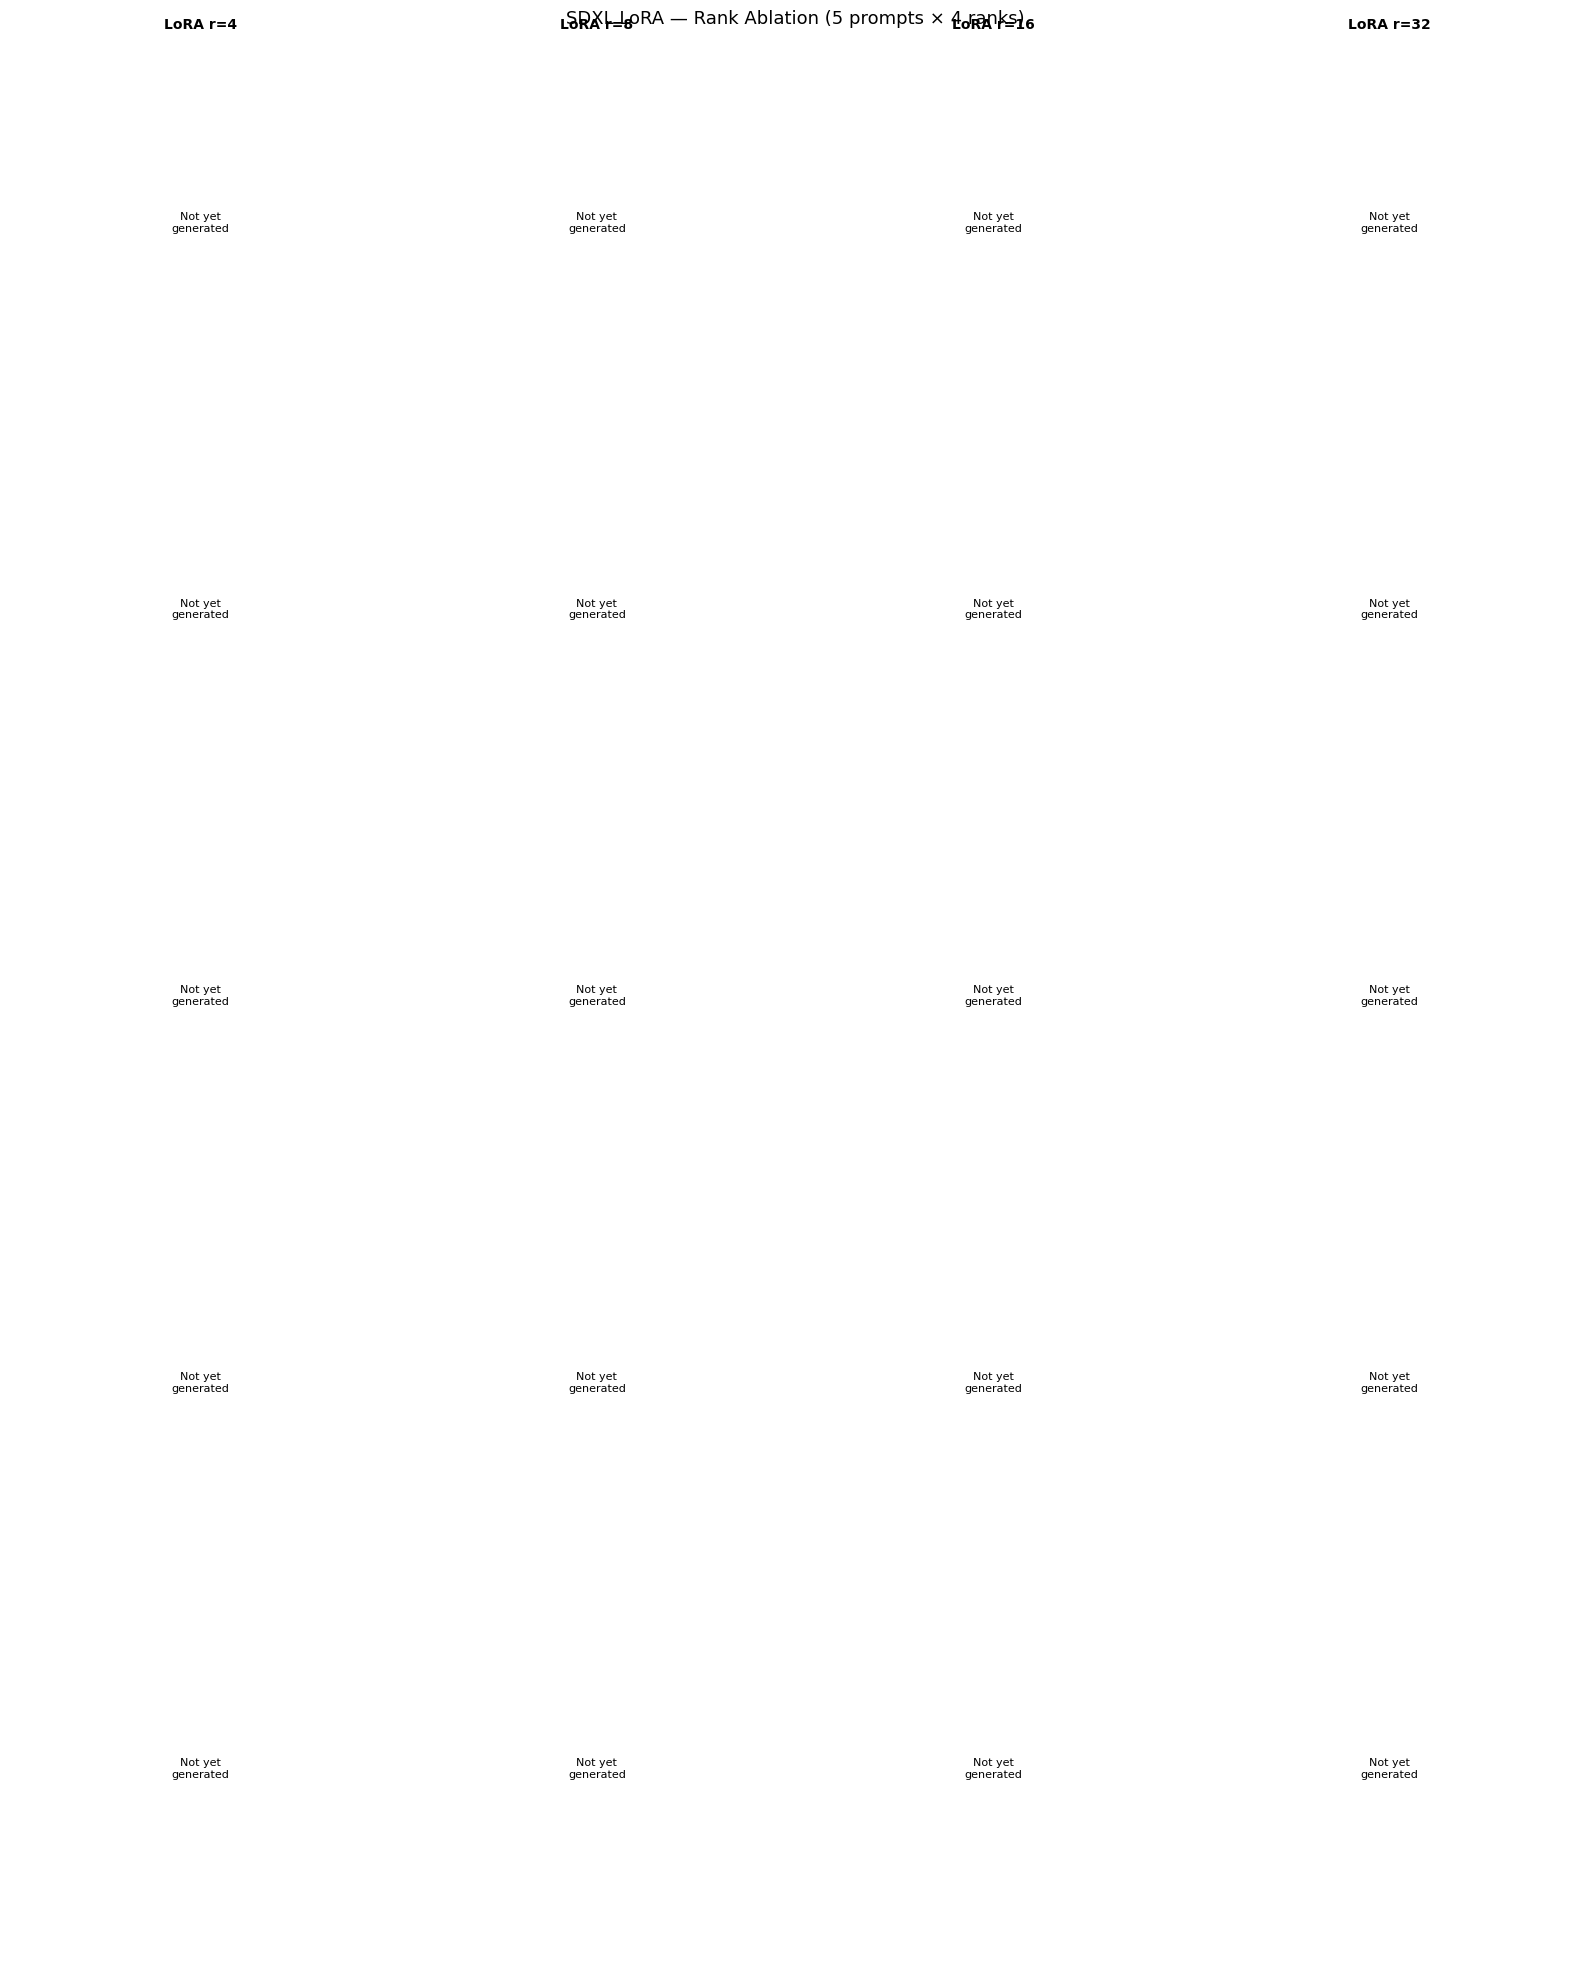

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

RANKS = [4, 8, 16, 32]

fig, axes = plt.subplots(5, 4, figsize=(16, 20))
for row in range(5):
    for col, rank in enumerate(RANKS):
        img_path = f'{DRIVE_ROOT}/results/experiments/sdxl_r{rank}_samples/prompt{row:02d}_v0.png'
        if Path(img_path).exists():
            axes[row, col].imshow(Image.open(img_path))
        else:
            axes[row, col].text(0.5, 0.5, "Not yet\ngenerated",
                                ha='center', va='center', fontsize=8)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(f'LoRA r={rank}', fontsize=10, fontweight='bold')

plt.suptitle("SDXL LoRA — Rank Ablation (5 prompts x 4 ranks)", fontsize=13)
plt.tight_layout()
plt.savefig(f'{DRIVE_ROOT}/results/experiments/rank_ablation_grid.png', dpi=150)
plt.show()
